# 01 · Keşifsel Veri Analizi (EDA)

**Amaç:** Modeli kurmadan önce dolandırıcılığın hangi koşullarda yoğunlaştığını anlamak ve
özellik, metrik ve doğrulama kararlarını veriye dayandırmak.

**Veri:** `data/processed/transactions.parquet` (üretmek için: `make data && make process`).
Analiz **yalnızca eğitim bölmesiyle** (2019-01-01 → 2020-03-31) yapılır. Doğrulama ve test
dönemlerine burada bakılmaz; aksi hâlde model kararları, sonradan ölçüleceği veriye göre
şekillenmiş olur.

> Not: Veri, Sparkov simülatörüyle üretilmiş **sentetik** kart işlemleridir. Bulgular bu
> simülatörün davranışını yansıtır; gerçek bankacılık verisine genellenmeleri sınırlıdır.

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

from card_fraud_detection.config import CARD_COL, REPORTS_DIR, TARGET, TIME_COL
from card_fraud_detection.data.clean import OUT_PATH

FIG_DIR = REPORTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Renk rolleri: dataviz referans paletinin ilk iki kategorik slotu (renk körlüğü
# doğrulayıcısından geçti). Kırmızı "kritik" durum rengine ayrıldığı için kullanılmıyor.
NORMAL, FRAUD = "#2a78d6", "#eb6834"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.dpi": 90, "savefig.dpi": 130, "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2,
    "ytick.labelcolor": INK2, "legend.frameon": False, "lines.linewidth": 2,
    "font.family": "DejaVu Sans",
})


def tr_pct(v, decimals=None):
    """Türkçe yüzde biçimi: %1,76. decimals verilmezse gereksiz sıfırlar atılır."""
    s = f"{v:g}" if decimals is None else f"{v:.{decimals}f}"
    return "%" + s.replace(".", ",")


PCT = mtick.FuncFormatter(lambda v, _: tr_pct(round(v, 3)))
USD = mtick.FuncFormatter(lambda v, _: f"${v:,.0f}")
CLASSES = [("Normal", 0, NORMAL), ("Dolandırıcılık", 1, FRAUD)]


def class_legend(ax, loc):
    """Sınıf lejantı: histogram kutuları yerine çizgi işaretleri."""
    handles = [plt.Line2D([], [], color=color, lw=2, label=label) for label, _, color in CLASSES]
    ax.legend(handles=handles, loc=loc)


def base_rate_line(ax, x, horizontal=True):
    """Genel oran çizgisi ve etiketi; etiket, çubukların alçak olduğu `x` konumuna yazılır."""
    if horizontal:
        ax.axhline(BASE_RATE, color=MUTED, lw=1)
        ax.annotate(f"genel oran {tr_pct(BASE_RATE, 2)}", (x, BASE_RATE), xytext=(0, 4),
                    textcoords="offset points", color=INK2, fontsize=9)
    else:
        ax.axvline(BASE_RATE, color=MUTED, lw=1)


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", facecolor=SURFACE)


def rate_table(frame, by):
    """Gruba göre işlem sayısı, dolandırıcılık sayısı, oranı (%) ve dolandırıcılıkların payı (%)."""
    g = frame.groupby(by, observed=True)[TARGET]
    out = pd.DataFrame({"işlem": g.size(), "dolandırıcılık": g.sum()})
    out["oran (%)"] = 100 * out["dolandırıcılık"] / out["işlem"]
    out["dolandırıcılık payı (%)"] = 100 * out["dolandırıcılık"] / out["dolandırıcılık"].sum()
    return out


full = pd.read_parquet(OUT_PATH)
df = full[full["split"] == "train"].reset_index(drop=True)
del full
df["hour"] = df[TIME_COL].dt.hour
df["dow"] = df[TIME_COL].dt.dayofweek
df["age"] = (df[TIME_COL] - df["dob"]).dt.days / 365.25
BASE_RATE = 100 * df[TARGET].mean()
print(f"{len(df):,} işlem · {df[TARGET].sum():,} dolandırıcılık · "
      f"genel oran {tr_pct(BASE_RATE, 2)}")

1,097,693 işlem · 6,343 dolandırıcılık · genel oran %0,58


## 1. Tutar

In [2]:
desc = df.groupby(TARGET)["amt"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
desc.index = ["normal", "dolandırıcılık"]
desc.round(2)

,count,mean,std,min,5%,25%,50%,75%,95%,max
normal,1091350.0,67.63,152.87,1.00,2.44,9.61,47.23,82.49,190.04,28948.90
dolandırıcılık,6343.0,531.05,391.14,1.06,9.10,242.88,395.30,901.82,1084.51,1371.81


,işlem,dolandırıcılık,oran (%),dolandırıcılık payı (%)
bin,,,,
<10,284290,446,0.16,7.03
10–50,285255,920,0.32,14.50
50–100,329455,39,0.01,0.61
100–200,146149,126,0.09,1.99
200–300,26812,671,2.50,10.58
300–500,12514,1058,8.45,16.68
500–1000,9889,2269,22.94,35.77
≥1000,3329,814,24.45,12.83


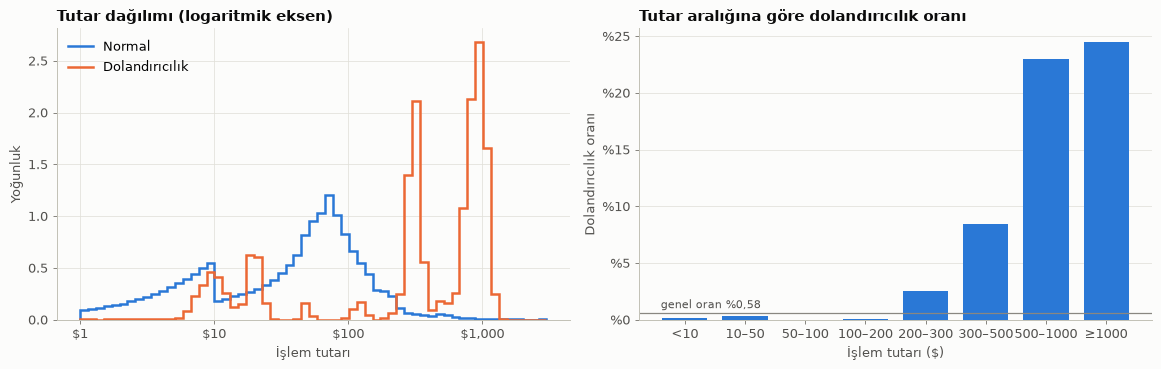

In [3]:
bins_log = np.linspace(0, np.log10(3000), 60)
amount_bins = [0, 10, 50, 100, 200, 300, 500, 1000, np.inf]
amount_labels = ["<10", "10–50", "50–100", "100–200", "200–300", "300–500", "500–1000", "≥1000"]
amt_rate = rate_table(df.assign(bin=pd.cut(df["amt"], amount_bins, labels=amount_labels,
                                           right=False)), "bin")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
for label, value, color in CLASSES:
    x = np.log10(df.loc[df[TARGET] == value, "amt"].clip(upper=2999))
    ax.hist(x, bins=bins_log, density=True, histtype="step", lw=2, color=color, label=label)
ax.set_xticks(np.log10([1, 10, 100, 1000]), ["$1", "$10", "$100", "$1,000"])
ax.set(title="Tutar dağılımı (logaritmik eksen)", xlabel="İşlem tutarı", ylabel="Yoğunluk")
class_legend(ax, "upper left")

ax = axes[1]
ax.bar(amt_rate.index.astype(str), amt_rate["oran (%)"], color=NORMAL, width=0.75)
base_rate_line(ax, -0.4)
ax.yaxis.set_major_formatter(PCT)
ax.set(title="Tutar aralığına göre dolandırıcılık oranı", xlabel="İşlem tutarı ($)",
       ylabel="Dolandırıcılık oranı")
ax.grid(axis="x", visible=False)
fig.tight_layout()
save(fig, "01_tutar")
amt_rate.round(2)

**Bulgular**
- Dolandırıcılık işlemleri çok daha yüksek tutarlı: medyan **$395**, normal işlemlerde **$47**.
  Dolandırıcılıkların %65'i $300 ve üzerinde. Oran $200'ün altında genel oranın altında kalıyor,
  $500–1.000 aralığında ise **%22,9**'a çıkıyor.
- Dolandırıcılık tutarları sürekli bir dağılım değil, birkaç dar **bantta** toplanıyor
  (belirgin olanları ~$250–350 ve ~$700–1.100). Bu, simülatörün dolandırıcılık senaryolarını
  sabit tutar aralıklarından ürettiğini gösteriyor.
- Dolandırıcılıkların %21,5'i $50'nin altında. Bu küçük işlemler tutarla ayırt edilemez;
  bağlam (kategori, saat, kart geçmişi) gerekir.
- **Simülatör kalıntısı:** En yüksek dolandırıcılık tutarı $1.371,81, normal işlemlerde ise
  $28.948. Model "tutar $1.372'yi aşıyorsa dolandırıcılık değildir" kuralını öğrenebilir.
  Gerçek dünyada karşılığı olmayan bu kural README'de sınırlama olarak belirtilecek; veriye
  müdahale edilmeyecek.

## 2. Kategori

,işlem,dolandırıcılık,oran (%),dolandırıcılık payı (%),medyan tutar: normal,medyan tutar: dolandırıcılık
category,,,,,,
shopping_net,82582,1456,1.76,22.95,8.29,997.06
misc_net,53406,776,1.45,12.23,9.69,792.00
grocery_pos,104507,1469,1.41,23.16,104.56,309.97
shopping_pos,98614,704,0.71,11.10,7.70,866.79
gas_transport,111314,522,0.47,8.23,62.91,10.72
misc_pos,67447,209,0.31,3.29,13.86,8.86
grocery_net,38371,116,0.30,1.83,51.01,12.54
travel,34358,103,0.30,1.62,6.25,9.71
entertainment,79668,201,0.25,3.17,50.42,502.25


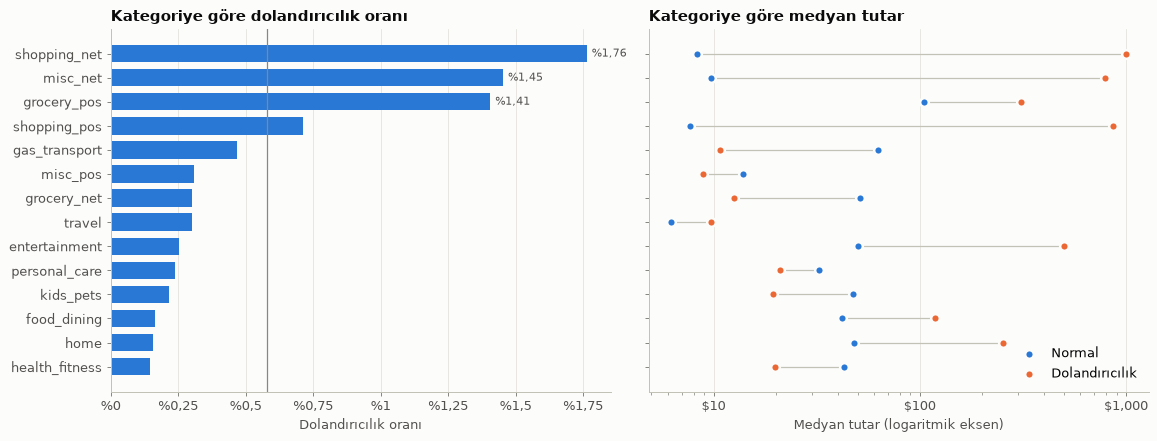

In [4]:
cat = rate_table(df, "category").sort_values("oran (%)")
med = df.groupby(["category", TARGET], observed=True)["amt"].median().unstack()
cat["medyan tutar: normal"] = med[0]
cat["medyan tutar: dolandırıcılık"] = med[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ax = axes[0]
ax.barh(cat.index.astype(str), cat["oran (%)"], color=NORMAL, height=0.72)
base_rate_line(ax, None, horizontal=False)
for name in cat.index[-3:]:                     # yalnızca en yüksek üç oran etiketlenir
    v = cat.loc[name, "oran (%)"]
    ax.annotate(tr_pct(v, 2), (v, str(name)), xytext=(4, 0), textcoords="offset points",
                va="center", color=INK2, fontsize=9)
ax.xaxis.set_major_formatter(PCT)
ax.set(title="Kategoriye göre dolandırıcılık oranı", xlabel="Dolandırıcılık oranı")
ax.grid(axis="y", visible=False)

ax = axes[1]
y = np.arange(len(cat))
ax.hlines(y, cat["medyan tutar: normal"], cat["medyan tutar: dolandırıcılık"], color=AXIS, lw=1)
ax.scatter(cat["medyan tutar: normal"], y, color=NORMAL, s=48, zorder=3, label="Normal",
           edgecolor=SURFACE, linewidth=2)
ax.scatter(cat["medyan tutar: dolandırıcılık"], y, color=FRAUD, s=48, zorder=3,
           label="Dolandırıcılık", edgecolor=SURFACE, linewidth=2)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(USD)
ax.set(title="Kategoriye göre medyan tutar", xlabel="Medyan tutar (logaritmik eksen)")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "02_kategori")
cat.round(2).iloc[::-1]

**Bulgular**
- En riskli üç kategori `shopping_net` (%1,76), `misc_net` (%1,45) ve `grocery_pos` (%1,41).
  İşlemlerin %22'sini oluşturan bu üç kategori, dolandırıcılıkların **%58**'ini içeriyor.
- **Tutarın anlamı kategoriye göre tersine dönüyor.** Çevrim içi alışverişte dolandırıcılığın
  medyan tutarı normalin ~120 katı ($997'ye $8). `gas_transport`, `grocery_net`, `kids_pets`,
  `personal_care` ve `health_fitness` kategorilerinde ise dolandırıcılık normalden **küçük**
  (akaryakıtta $11'e $63). Tek başına "yüksek tutar = risk" kuralı bu kategorilerde yanılır.
- **Karar:** Kategori doğrudan özellik olacak. Buna ek olarak "tutarın kategori medyanına oranı"
  eklenecek; kategori medyanları **yalnızca eğitim bölmesinden** hesaplanacak. Ağaç tabanlı
  modeller bu etkileşimi kendileri de öğrenebilir; bu özellik öğrenmeyi kolaylaştırır.

## 3. Saat ve haftanın günü

Gece (22:00–03:59) işlem payı %23,5, dolandırıcılık payı %84,7


,işlem,dolandırıcılık,oran (%),dolandırıcılık payı (%)
Pzt,215504,999,0.46,15.75
Sal,123137,770,0.63,12.14
Çar,111785,697,0.62,10.99
Per,125450,830,0.66,13.09
Cum,127995,923,0.72,14.55
Cmt,176774,1087,0.61,17.14
Paz,217048,1037,0.48,16.35


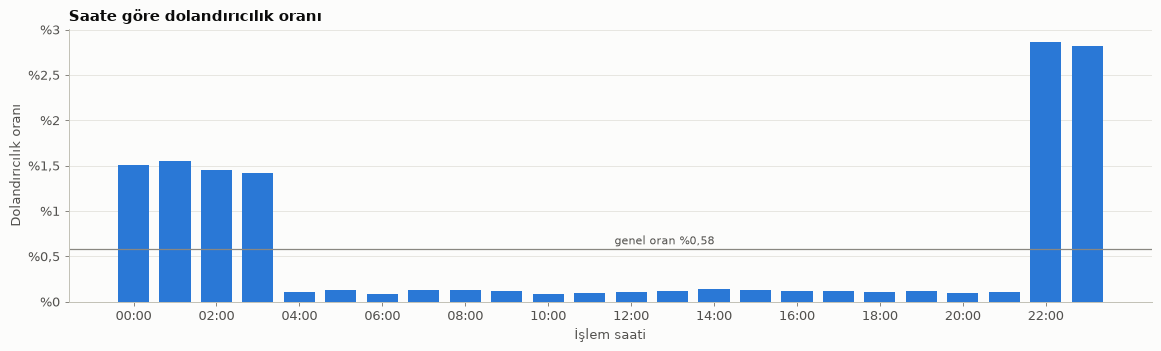

In [5]:
hour = rate_table(df, "hour")
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(hour.index, hour["oran (%)"], color=NORMAL, width=0.75)
base_rate_line(ax, 11.6)                        # gündüz çubukları alçak, etiket oraya yazılır
ax.set_xticks(range(0, 24, 2), [f"{h:02d}:00" for h in range(0, 24, 2)])
ax.yaxis.set_major_formatter(PCT)
ax.set(title="Saate göre dolandırıcılık oranı", xlabel="İşlem saati", ylabel="Dolandırıcılık oranı")
ax.grid(axis="x", visible=False)
fig.tight_layout()
save(fig, "03_saat")

night = df["hour"].isin([22, 23, 0, 1, 2, 3])
print(f"Gece (22:00–03:59) işlem payı {tr_pct(100 * night.mean(), 1)}, dolandırıcılık payı "
      f"{tr_pct(100 * df.loc[night, TARGET].sum() / df[TARGET].sum(), 1)}")
dow = rate_table(df, "dow")
dow.index = ["Pzt", "Sal", "Çar", "Per", "Cum", "Cmt", "Paz"]
dow.round(2)

**Bulgular**
- Dolandırıcılık neredeyse tamamen gece: 22:00–23:59 arasında oran ~%2,9, 00:00–03:59 arasında
  ~%1,5, gündüz (04:00–21:59) ise ~%0,1. Gece saatleri işlemlerin %23,5'ini, dolandırıcılıkların
  ise **%84,7**'sini oluşturuyor.
- Haftanın gününe göre fark zayıf (%0,46–0,72). En düşük oranlar, işlem hacminin en yüksek
  olduğu Pazartesi ve Pazar günlerinde; bu fark daha çok hacimden kaynaklanıyor.
- **Karar:** Saat (0–23) ve gece bayrağı özellik olacak. Haftanın günü zayıf bir özellik olarak
  eklenecek; katkısı Faz 3'te SHAP ile kontrol edilecek.

## 4. Kart geçmişi: patlamalar ve hız

Veri kalite raporu (§8), dolandırıcılığın kart başına ~2 günlük tek bir patlama hâlinde
geldiğini gösterdi. Bu bölüm, patlamanın **işlem anında görülebilen** izlerini arar:
kartın son 24 saatteki işlem sayısı ve tutarı, önceki işlemden bu yana geçen süre ve tutarın
kartın geçmiş ortalamasına oranı. Hepsi yalnızca **geçmiş** işlemlerden hesaplanır.

In [6]:
# Kart ve zamana göre sırala; groupby-rolling çıktısı aynı sırada gelir
df = df.sort_values([CARD_COL, TIME_COL], kind="stable").reset_index(drop=True)
roll = df.set_index(TIME_COL).groupby(CARD_COL)["amt"].rolling("24h", closed="left")
# o anki işlem hariç; boş pencere 0 işlemdir (NaN bırakılırsa bu satırlar analizden düşer)
df["n_24h"] = roll.count().fillna(0).to_numpy()
df["amt_24h"] = roll.sum().fillna(0).to_numpy()
g = df.groupby(CARD_COL)
df["hrs_since_prev"] = g[TIME_COL].diff().dt.total_seconds() / 3600
past_mean = g["amt"].transform(lambda s: s.shift().expanding().mean())
df["amt_vs_card_mean"] = df["amt"] / past_mean

cols = ["n_24h", "amt_24h", "hrs_since_prev", "amt_vs_card_mean"]
df.groupby(TARGET)[cols].median().rename(index={0: "normal", 1: "dolandırıcılık"}).round(2)

,n_24h,amt_24h,hrs_since_prev,amt_vs_card_mean
is_fraud,,,,
normal,3.0,171.64,4.60,0.66
dolandırıcılık,4.0,1687.41,1.33,5.19


Örnek kart dolandırıcılık sayısı: 10


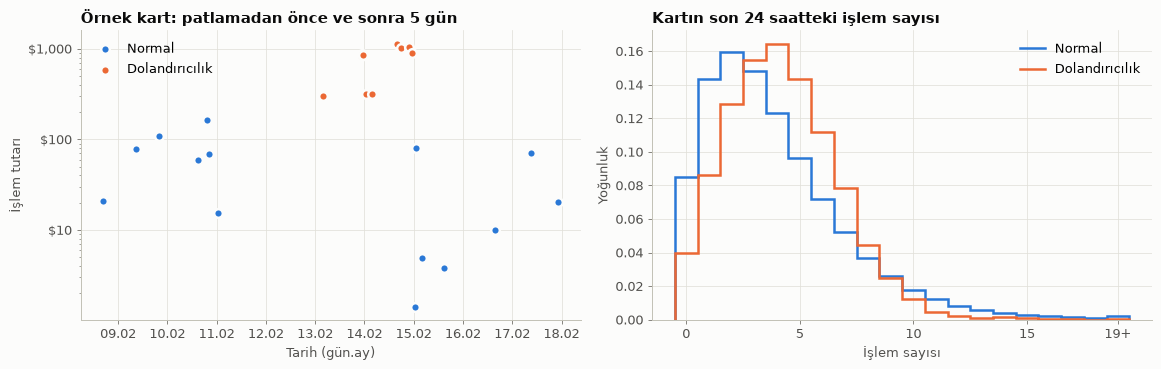

In [7]:
# Örnek kart: patlamanın çevresindeki 10 gün
fraud_cards = df.loc[df[TARGET] == 1, CARD_COL].value_counts()
card = fraud_cards.index[len(fraud_cards) // 2]            # medyan büyüklükte bir patlama
c = df[df[CARD_COL] == card]
t0 = c.loc[c[TARGET] == 1, TIME_COL].min()
w = c[(c[TIME_COL] >= t0 - pd.Timedelta(days=5)) & (c[TIME_COL] <= t0 + pd.Timedelta(days=5))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
for label, value, color in CLASSES:
    s = w[w[TARGET] == value]
    ax.scatter(s[TIME_COL], s["amt"], color=color, s=48, label=label, zorder=3,
               edgecolor=SURFACE, linewidth=2)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(USD)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.set(title="Örnek kart: patlamadan önce ve sonra 5 gün", ylabel="İşlem tutarı",
       xlabel="Tarih (gün.ay)")
ax.legend(loc="upper left")

ax = axes[1]
bins = np.arange(0, 21) - 0.5
for label, value, color in CLASSES:
    ax.hist(df.loc[df[TARGET] == value, "n_24h"].clip(upper=19), bins=bins, density=True,
            histtype="step", lw=2, color=color, label=label)
ax.set_xticks([0, 5, 10, 15, 19], ["0", "5", "10", "15", "19+"])
ax.set(title="Kartın son 24 saatteki işlem sayısı", xlabel="İşlem sayısı", ylabel="Yoğunluk")
class_legend(ax, "upper right")
fig.tight_layout()
save(fig, "04_patlama")
print("Örnek kart dolandırıcılık sayısı:", int(c[TARGET].sum()))

,işlem,dolandırıcılık,oran (%),dolandırıcılık payı (%)
bin,,,,
"<0,5",461631,1342,0.29,21.36
"0,5–1",275998,171,0.06,2.72
1–2,243220,352,0.14,5.60
2–3,70532,306,0.43,4.87
3–5,24426,870,3.56,13.85
5–10,13486,1200,8.90,19.10
≥10,7432,2042,27.48,32.50


,işlem,dolandırıcılık,oran (%),dolandırıcılık payı (%)
bin,,,,
0,92912,251,0.27,3.96
1–2,331759,1360,0.41,21.44
3–5,404496,2929,0.72,46.18
6–9,205472,1649,0.80,26.00
10–14,52752,143,0.27,2.25
≥15,10302,11,0.11,0.17


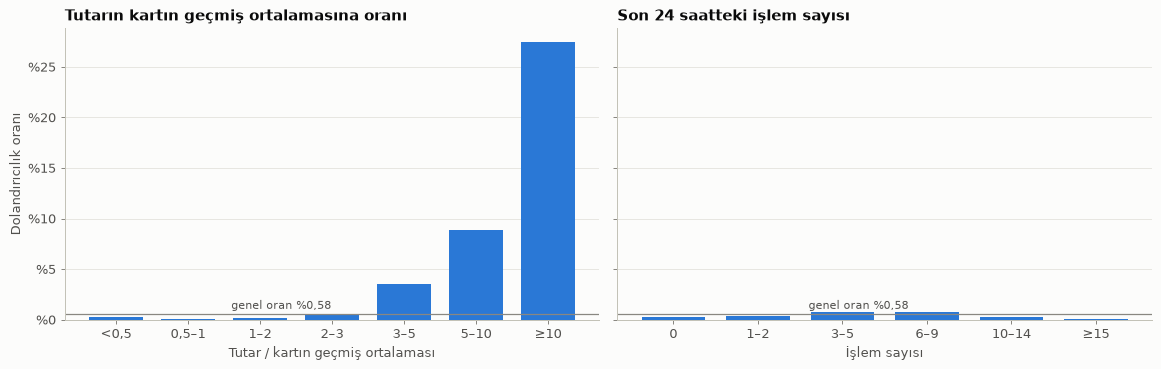

In [8]:
ratio_bins = [0, 0.5, 1, 2, 3, 5, 10, np.inf]
ratio_labels = ["<0,5", "0,5–1", "1–2", "2–3", "3–5", "5–10", "≥10"]
ratio = rate_table(df.dropna(subset=["amt_vs_card_mean"]).assign(
    bin=pd.cut(df["amt_vs_card_mean"], ratio_bins, labels=ratio_labels, right=False)), "bin")
n24 = rate_table(df.assign(bin=pd.cut(df["n_24h"], [0, 1, 3, 6, 10, 15, np.inf],
                                      labels=["0", "1–2", "3–5", "6–9", "10–14", "≥15"],
                                      right=False)), "bin")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, tbl, title, xlabel in [
    (axes[0], ratio, "Tutarın kartın geçmiş ortalamasına oranı", "Tutar / kartın geçmiş ortalaması"),
    (axes[1], n24, "Son 24 saatteki işlem sayısı", "İşlem sayısı"),
]:
    ax.bar(tbl.index.astype(str), tbl["oran (%)"], color=NORMAL, width=0.75)
    base_rate_line(ax, 1.6)
    ax.set(title=f"{title}", xlabel=xlabel)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Dolandırıcılık oranı")
axes[0].yaxis.set_major_formatter(PCT)
fig.tight_layout()
save(fig, "05_hiz_oran")
display(ratio.round(2), n24.round(2))

In [9]:
# Patlamanın ilk dolandırıcılık işlemi: kartın geçmişinde hiç dolandırıcılık yokken görülen işlem.
# Model patlamayı ne kadar erken yakalarsa o kadar değerli; ilk işlemdeki sinyaller ayrıca önemli.
first = df[df[TARGET] == 1].groupby(CARD_COL).head(1)
rest = df[df[TARGET] == 1].drop(first.index)
normal = df[df[TARGET] == 0]
pd.DataFrame({
    "normal": normal[cols].median(),
    "patlamanın ilk işlemi": first[cols].median(),
    "patlamanın sonraki işlemleri": rest[cols].median(),
}).round(2)

,normal,patlamanın ilk işlemi,patlamanın sonraki işlemleri
n_24h,3.00,1.00,4.00
amt_24h,171.64,38.98,1939.08
hrs_since_prev,4.60,12.37,1.07
amt_vs_card_mean,0.66,5.07,5.21


**Bulgular**
- **Patlamayı ele veren, işlem sayısı değil tutar.** Son 24 saatteki işlem sayısının medyanı
  normalde 3, dolandırıcılıkta 4. İşlem sayısına göre oran dar bir aralıkta kalıyor: en yüksek
  6–9 işlemde (%0,80), 10–14 işlemde %0,27, 15 ve üzerinde %0,11. Çok işlem yapan kartlar
  çoğunlukla normal. Buna karşılık son 24 saatteki toplam tutarın medyanı dolandırıcılıkta
  **$1.687**, normalde **$172**.
- **Tutarın kartın geçmiş ortalamasına oranı en güçlü sinyal.** Medyan oran dolandırıcılıkta
  5,2, normalde 0,66. Oranı 3'ün üzerinde olan işlemler tüm işlemlerin %4'ü, ama
  dolandırıcılıkların **%65**'i. Oran 10'u geçince dolandırıcılık oranı %27,5.
- **Patlamanın ilk işlemi farklı görünüyor.** İlk dolandırıcılıkta kart sakin: son 24 saatte
  medyan 1 işlem ve $39, önceki işlemden bu yana geçen süre 12,4 saat (normalden **uzun**).
  Tutar oranı ise daha ilk işlemde 5,1. Sonraki işlemlerde 24 saatlik tutar $1.939'a çıkıyor,
  işlemler arası süre 1,1 saate iniyor.
  → İlk işlemi **tutar–geçmiş karşılaştırması, kategori ve saat** yakalar; birikimli tutar
  özellikleri ise patlamanın devamını yakalar.
- Örnek kart: Birkaç günlük normal kullanımın ardından ~2 gün içinde $300–1.100 aralığında
  10 işlem geliyor, sonra kart normal kullanıma dönüyor.
- **Kararlar (Faz 2.1):**
  - Kartın geçmişe göre tutar sapması (oran ve z-skoru) ana özellik olacak.
  - 1 saat, 24 saat ve 7 günlük pencerelerde işlem sayısı ve toplam tutar hesaplanacak.
  - Önceki işlemden bu yana geçen süre de özellik olacak.
- **Karar (Faz 2.2):** İşlem bazlı metriklere ek olarak **patlama bazlı** metrik raporlanacak:
  patlama yakalandı mı, kaçıncı işlemde yakalandı, yakalanana kadar kaybedilen tutar ne kadar.

## 5. Müşteri–satıcı mesafesi

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
normal,1091350.0,76.1,29.1,0.0,55.3,78.2,98.5,152.1
dolandırıcılık,6343.0,76.2,28.7,0.7,55.6,77.8,98.3,144.5


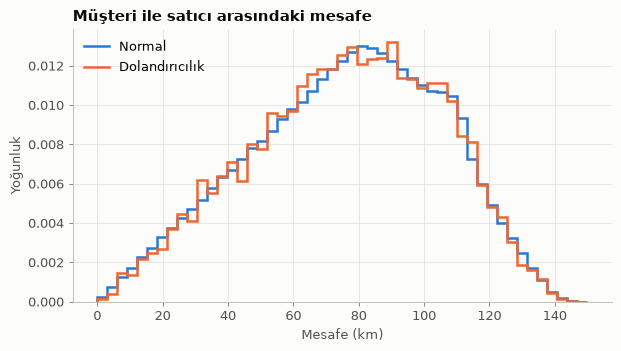

In [10]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 6371 * 2 * np.arcsin(np.sqrt(a))


df["dist_km"] = haversine_km(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 150, 50)
for label, value, color in CLASSES:
    ax.hist(df.loc[df[TARGET] == value, "dist_km"], bins=bins, density=True, histtype="step",
            lw=2, color=color, label=label)
ax.set(title="Müşteri ile satıcı arasındaki mesafe", xlabel="Mesafe (km)", ylabel="Yoğunluk")
class_legend(ax, "upper left")
fig.tight_layout()
save(fig, "06_mesafe")
df.groupby(TARGET)["dist_km"].describe().rename(index={0: "normal", 1: "dolandırıcılık"}).round(1)

**Bulgular**
- Mesafe dağılımları iki sınıfta neredeyse birebir aynı (medyan 78 km). Simülatör, satıcı
  konumunu dolandırıcılıktan bağımsız olarak müşterinin çevresinde rastgele üretiyor.
- **Karar:** Müşteri–satıcı mesafesi ve ardışık işlemler arası hız ("imkânsız yolculuk")
  özellikleri plandan **çıkarıldı**. Gerçek veride güçlü olabilecek bu sinyal bu veri setinde
  yok; README'de sınırlama olarak belirtilecek.

## 6. Demografi

,işlem,dolandırıcılık,oran (%),dolandırıcılık payı (%)
bin,,,,
<25,103727,693,0.67,10.93
25–34,246109,1146,0.47,18.07
35–44,229796,998,0.43,15.73
45–54,216437,1255,0.58,19.79
55–64,139382,1076,0.77,16.96
65–74,83731,480,0.57,7.57
≥75,78511,695,0.89,10.96


,işlem,dolandırıcılık,oran (%),dolandırıcılık payı (%)
gender,,,,
F,601064,3141,0.52,49.52
M,496629,3202,0.64,50.48


,işlem,dolandırıcılık,oran (%),dolandırıcılık payı (%)
şehir nüfusu (beşte birlik dilimler),,,,
23–568,220663,1300,0.59,20.50
"568–1,631",219234,1184,0.54,18.67
"1,631–4,720",218947,1227,0.56,19.34
"4,720–42,619",220019,1312,0.60,20.68
"42,619–2,906,700",218830,1320,0.60,20.81


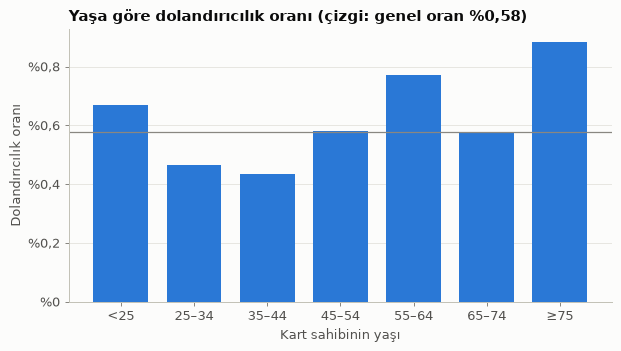

In [11]:
age = rate_table(df.assign(bin=pd.cut(df["age"], [0, 25, 35, 45, 55, 65, 75, 120],
                                      labels=["<25", "25–34", "35–44", "45–54", "55–64",
                                              "65–74", "≥75"], right=False)), "bin")
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(age.index.astype(str), age["oran (%)"], color=NORMAL, width=0.75)
ax.axhline(BASE_RATE, color=MUTED, lw=1)        # çubuklar çizgiye yakın; etiket başlıkta
ax.yaxis.set_major_formatter(PCT)
ax.set(title=f"Yaşa göre dolandırıcılık oranı (çizgi: genel oran {tr_pct(BASE_RATE, 2)})",
       xlabel="Kart sahibinin yaşı",
       ylabel="Dolandırıcılık oranı")
ax.grid(axis="x", visible=False)
fig.tight_layout()
save(fig, "07_yas")
display(age.round(2))
display(rate_table(df, "gender").round(2))
pop = rate_table(df.assign(bin=pd.qcut(df["city_pop"], 5)), "bin")
pop.index = [f"{i.left:,.0f}–{i.right:,.0f}" for i in pop.index]
pop.index.name = "şehir nüfusu (beşte birlik dilimler)"
pop.round(2)

**Bulgular**
- Yaşa göre hafif U biçimli bir ilişki var: 35–44 yaşta %0,43, 75 yaş ve üzerinde %0,89.
  Cinsiyete göre fark küçük (kadın %0,52, erkek %0,64). Şehir nüfusunda fark yok (%0,54–0,60).
- **Karar:** Yaş ve cinsiyet korunan özelliklerdir; zayıf sinyal için bunları kullanmak adalet
  (fairness) ve mevzuat riski taşır. Ana model **demografik özellik kullanmayacak.** Faz 3'te
  yaş ve cinsiyetin eklendiği bir karşılaştırma modeli kurulup katkıları ölçülecek. Şehir
  nüfusu sinyal taşımadığı için kullanılmayacak.

## 7. Özet ve sonraki fazlara aktarılan kararlar

| Bulgu | Kanıt (eğitim bölmesi) | Karar |
|---|---|---|
| Tutar en güçlü tekil sinyal | Medyan $395'e $47; $500–1.000'de oran %22,9 | Tutar ve log tutar |
| Tutarın anlamı kategoriye bağlı | Çevrim içi alışverişte ~120 kat büyük, akaryakıtta ~6 kat küçük | Kategori + tutar/kategori medyanı (yalnızca eğitimden) |
| Dolandırıcılık gece yoğunlaşıyor | İşlemlerin %23,5'i, dolandırıcılığın %84,7'si gece | Saat + gece bayrağı |
| Patlamayı tutar ele veriyor, işlem sayısı değil | 24 saatlik tutar $1.687'ye $172; işlem sayısı medyanı 3'e 4 | 1 sa / 24 sa / 7 g toplam tutar ve sayı |
| Kart geçmişine göre sapma en güçlü sinyal | Oran > 3 olan işlemler: işlemlerin %4'ü, dolandırıcılığın %65'i | Kart geçmişine göre oran ve z-skoru |
| Patlamanın ilk işlemi sakin görünüyor | İlk işlemde 24 saatlik tutar $39, ama oran zaten 5,1 | Patlama bazlı metrik (Faz 2.2) |
| Mesafe sinyal taşımıyor | İki dağılım aynı | Mesafe ve hız özellikleri plandan çıktı |
| Demografik sinyal zayıf | Yaşa göre %0,43–0,89 | Ana model demografisiz; Faz 3'te karşılaştırma |
| Simülatör kalıntısı | Dolandırıcılıkta en yüksek tutar $1.372 | README'de sınırlama |